## Student Name: Gabriel Espinoza Rojas

## Student ID: 22176691

## Please do not add further imports. If you think an import is missing, please contact your moderator.

The notebook provides empty cells for your answer to give you guidance on the answer expected from you. You may add cells, but please note this may mean you go beyond what is expected from you and, if this results in unnecessary/unrelated content being added, may reduce your grade.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neural_network import MLPClassifier
from sklearn import svm

from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from skopt.utils import use_named_args

import sys
np.set_printoptions(threshold=sys.maxsize)
import time

# Task 1
## Task 1 Code
The below code is not necessarily complete or applicable to all tasks. Read and understand the code so that you can use wisely and adapt as required.

In [2]:
# this cell has been modified to add information to the plots

def custom_formatter(x):
    if x == 0:
        return "decision boundary"
    else:
        return "margin"

def plot_margin_with_extra_labels(X, y, clf):
    plt.scatter(X[y==0][:,0], X[y==0][:,1], label="Class 0")
    plt.scatter(X[y==1][:,0], X[y==1][:,1], label="Class 1")


    # plot the decision function
    ax = plt.gca()
    ax.set_aspect(aspect=1)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # plot decision boundary and margins
    margins = ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    ax.clabel(margins, fmt=custom_formatter, inline=True, fontsize=8)
    
    # plot support vectors
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k', label="Support Vectors")
    ax.legend()

## Task 1 Instructions 

1. Load dataset Et3_Task1.csv and use a suitable plot to investigate the data.
    - You do not need to look at out-of-sample performance. Hence, there is no '_test' set. Use all available data for training.
2. Perform classification on this dataset using an SVM with linear kernel choosing the C parameter to obtain a hard margin.
    - In a plot containing the data, plot the SVM margins indicating the support vectors.
    - Extract the numerical representation of the support vectors from the trained model.
    - Obtain the performance of your model on training data.
3. Perform classification on this dataset using an SVM with linear kernel choosing the C parameter to obtain a soft margin with a maximum of 15 support vectors.
    - In a plot containing the data, plot the SVM margins indicating the support vectors.
    - Extract the numerical representation of each support vector from the trained model.
    - Obtain the performance of your model on training data.
    - Using information provided by your trained model, identify which of the support vectors lie inside the margin (i.e. are soft margin support vectors).
4. Answer the following questions:
      1. Explain how and why the width of the margin changes as you increase / decrease the C-parameter? Relate this to the Hinge loss error measure (including the regularisation term) used in SVMs. (100 words max)
    2. How and why does the width of the margin affect the expected generalisation abilities of the model? (100 words max)
    3. For the soft-margin model, provide the coordinates of the support vectors that do not violate the margin. (100 words max)

## Task 1 Answer
We suggest to stick to the number of cells provided below.

## 1. Load dataset Et3_Task1.csv and use a suitable plot to investigate the data.
    - You do not need to look at out-of-sample performance. Hence, there is no '_test' set. Use all available data for training.

(1001, 2)
(1001,)


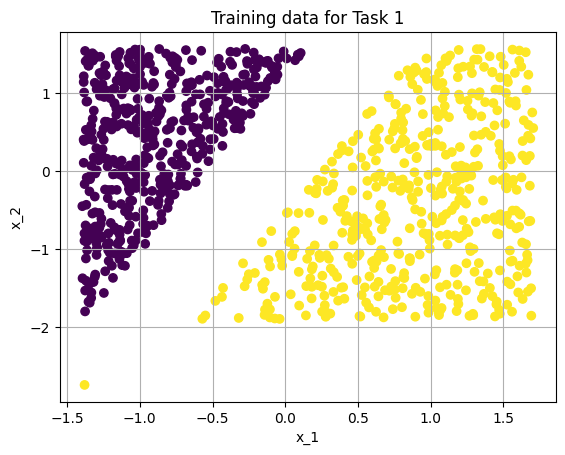

In [3]:
data_task1 = np.loadtxt("Et3_Task1.csv", delimiter=",")
X_Task1 = data_task1[:,0:2]
y_Task1 = data_task1[:,2]

print(np.shape(X_Task1))
print(np.shape(y_Task1))
plt.scatter(X_Task1[:, 0], X_Task1[:, 1], c=y_Task1)
plt.title("Training data for Task 1")
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.grid()

### 2. Perform classification on this dataset using an SVM with linear kernel choosing the C parameter to obtain a hard margin.
    - In a plot containing the data, plot the SVM margins indicating the support vectors.
    - Extract the numerical representation of the support vectors from the trained model.
    - Obtain the performance of your model on training data.

Linear kernel with hard margin (C=1000000.0)

Margin width: 0.2239


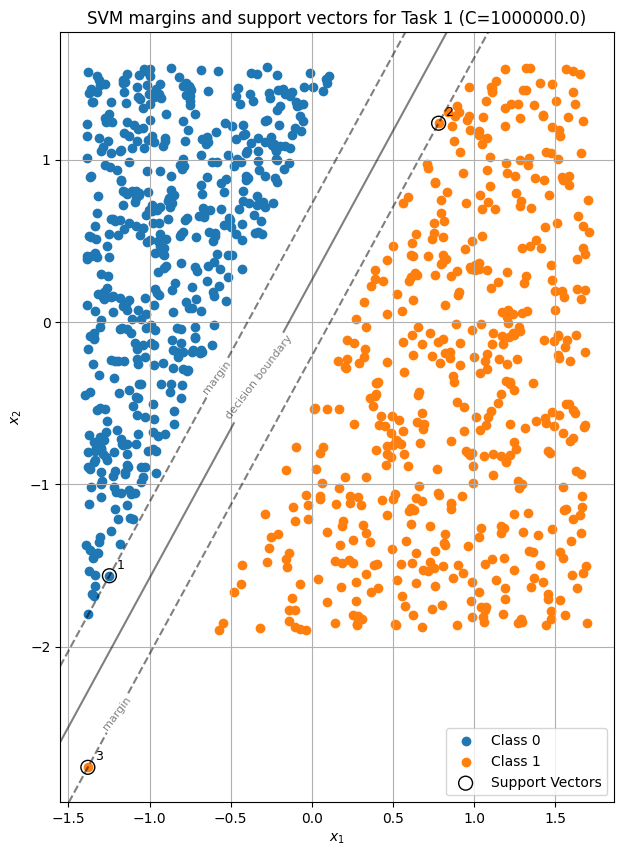

Numerical representation of the support vectors:
Support Vector 1: x_1[-1.2472] x_2[-1.5625]
Support Vector 2: x_1[0.7804] x_2[1.2247]
Support Vector 3: x_1[-1.3800] x_2[-2.7426]
Performance:
Accuracy: 100.00%
E_in: 0.0000


In [78]:
#default 1.0, but we want to use a hard margin SVM, so we set C to a very large value
hard_margin_C = 1e6

linear_support_vector_classifier_hard_margin_task1 = svm.SVC(C=hard_margin_C, kernel='linear', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, 
                                                  cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=0)

linear_support_vector_classifier_hard_margin_task1.fit(X_Task1, y_Task1)

support_vectors = linear_support_vector_classifier_hard_margin_task1.support_vectors_

print(f"Linear kernel with hard margin (C={hard_margin_C})")
# Margin width for model (C_hard)
margin_hard = 1 / np.linalg.norm(linear_support_vector_classifier_hard_margin_task1.coef_)
print(f"\nMargin width: {margin_hard:.4f}")

plt.figure(figsize=(10,10))
plot_margin_with_extra_labels(X_Task1, y_Task1, linear_support_vector_classifier_hard_margin_task1)
plt.title(f"SVM margins and support vectors for Task 1 (C={hard_margin_C})")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.grid()

# let's label each support vector with its index for reference in the numerical representation
for i in range(len(support_vectors)):
    plt.annotate(str(i+1),
                (support_vectors[i,0], support_vectors[i,1]),
                textcoords="offset points",
                xytext=(5,5),
                fontsize=9)

plt.show()


print("Numerical representation of the support vectors:")
for i, support_vector in enumerate(support_vectors):
    print(f"Support Vector {i+1}: x_1[{support_vector[0]:.4f}] x_2[{support_vector[1]:.4f}]")

print("Performance:")
# check accuracy // E_in
accuracy = np.mean(linear_support_vector_classifier_hard_margin_task1.predict(X_Task1) == y_Task1)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")

### 3. Perform classification on this dataset using an SVM with linear kernel choosing the C parameter to obtain a soft margin with a maximum of 15 support vectors.
    - In a plot containing the data, plot the SVM margins indicating the support vectors.
    - Extract the numerical representation of each support vector from the trained model.
    - Obtain the performance of your model on training data.
    - Using information provided by your trained model, identify which of the support vectors lie inside the margin (i.e. are soft margin support vectors).

Linear kernel with soft margin (C=0.7)

Margin width: 0.3694


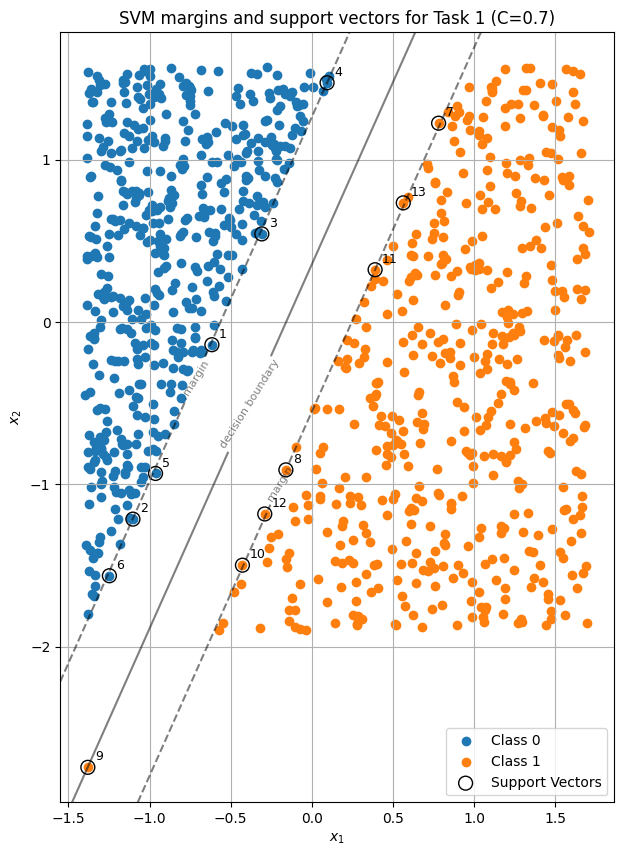

Numerical representation of the support vectors:
Support Vector 1: x_1[-0.6160] x_2[-0.1395], Inside margin
    slack: 0.023, alpha: 0.700
Support Vector 2: x_1[-1.1022] x_2[-1.2138], Inside margin
    slack: 0.005, alpha: 0.700
Support Vector 3: x_1[-0.3084] x_2[0.5429], Inside margin
    slack: 0.032, alpha: 0.700
Support Vector 4: x_1[0.0935] x_2[1.4738], On the margin
    slack: 0.000, alpha: 0.590
Support Vector 5: x_1[-0.9632] x_2[-0.9325], Inside margin
    slack: 0.039, alpha: 0.700
Support Vector 6: x_1[-1.2472] x_2[-1.5625], Inside margin
    slack: 0.031, alpha: 0.700
Support Vector 7: x_1[0.7804] x_2[1.2247], Inside margin
    slack: 0.027, alpha: 0.700
Support Vector 8: x_1[-0.1602] x_2[-0.9105], On the margin
    slack: 0.000, alpha: 0.253
Support Vector 9: x_1[-1.3800] x_2[-2.7426], Inside margin
    slack: 0.997, alpha: 0.700
Support Vector 10: x_1[-0.4279] x_2[-1.4975], Inside margin
    slack: 0.015, alpha: 0.700
Support Vector 11: x_1[0.3893] x_2[0.3224], On the marg

In [73]:
#default 1.0, but we want to use a soft margin SVM, so we set C to a very small value
soft_margin_C = 0.70

linear_support_vector_classifier_soft_margin_task1 = svm.SVC(C=soft_margin_C, kernel='linear', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, 
                                                  cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=0)


linear_support_vector_classifier_soft_margin_task1.fit(X_Task1, y_Task1)


support_vectors = linear_support_vector_classifier_soft_margin_task1.support_vectors_

print(f"Linear kernel with soft margin (C={soft_margin_C})")
# Margin width for model (soft margin)
margin_soft = 1 / np.linalg.norm(linear_support_vector_classifier_soft_margin_task1.coef_)
print(f"\nMargin width: {margin_soft:.4f}")
plt.figure(figsize=(10,10))
plot_margin_with_extra_labels(X_Task1, y_Task1, linear_support_vector_classifier_soft_margin_task1)
plt.title(f"SVM margins and support vectors for Task 1 (C={soft_margin_C})")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.grid()

# let's label each support vector with its index for reference in the numerical representation
for i in range(len(support_vectors)):
    plt.annotate(str(i+1),
                (support_vectors[i,0], support_vectors[i,1]),
                textcoords="offset points",
                xytext=(5,5),
                fontsize=9)

plt.show()

support_vector_indices = linear_support_vector_classifier_soft_margin_task1.support_

# y classes are assigned to values 0 and 1, but for an accurate numerical representation we need [-1 1]
y_signed = y_Task1*2-1
# distance from the decision boundary for each support vector
distances =  linear_support_vector_classifier_soft_margin_task1.decision_function(support_vectors)
slacks = np.maximum(0, 1 - y_signed[support_vector_indices] * distances)  

# In sklearn, dual_coef_ is y_n * alpha_n
alphas = np.abs(linear_support_vector_classifier_soft_margin_task1.dual_coef_[0])

print("Numerical representation of the support vectors:")
for i, support_vector in enumerate(support_vectors):
    # Pep said it was ok to take the alpha values at face value (no epsilon for tolerance)
    if 0 < alphas[i] and alphas[i] < soft_margin_C:
        print(f"Support Vector {i+1}: x_1[{support_vector[0]:.4f}] x_2[{support_vector[1]:.4f}], On the margin")
    elif alphas[i] == soft_margin_C and slacks[i] <= 1:
        print(f"Support Vector {i+1}: x_1[{support_vector[0]:.4f}] x_2[{support_vector[1]:.4f}], Inside margin")
    else:
        print(f"Support Vector {i+1}: x_1[{support_vector[0]:.4f}] x_2[{support_vector[1]:.4f}], Misclassified")

    print(f"    slack: {slacks[i]:.3f}, alpha: {alphas[i]:.3f}")


# check accuracy // E_in
accuracy = np.mean(linear_support_vector_classifier_soft_margin_task1.predict(X_Task1) == y_Task1)       
print(f"Accuracy: {accuracy * 100:.2f}%")

print("15 support vectors max? only using", len(linear_support_vector_classifier_soft_margin_task1.support_vectors_))

### 4. Answer the following questions:
    1. Explain how and why the width of the margin changes as you increase / decrease the C-parameter? Relate this to the Hinge loss error measure (including the regularisation term) used in SVMs. (100 words max)

The SVM optimisation expressed in conjunction with the hinge loss is: $ min \frac{w^T w}{2} + C \sum_{n=1}^{N}\xi_n$, when $C$ is very large (essentially, no regularisation), the hinge loss gets so penalised that the application of Lagrange multipliers forces the term $\sum_{n=1}^{N}\xi_n$ to zero. What's a large $C$? A $C$ that creates zero violations of the margins, which also means narrowed margins as no data point can cross the margin lines. As $C$ is reduced, the slack $\xi$ values get some room to breathe, the margins relax and small $\xi$ losses are added to the outcome.


<b>2. How and why does the width of the margin affect the expected generalisation abilities of the model? (100 words max)</b>

Narrow margins 'listen' more to the data, which can lead to overfitting, we can see this behaviour in the data set, where a single outlier and support vector (labelled '3' in our first plot for the large $C$) drastically narrows our $C$ decision boundary in comparasion with our second plot ($0.2239$ vs $0.3694$). Wider margins might not have an $E_{in}$ as low as a narrow margin, but they tend to generalise better (lower $E_{out}$) because the decision boundary is less sensitive to small variations in the data and helps the model handle data that is not perfectly separable.


they also give the model the advantage to work in <i>almost</i> linearly separable data sets, without the need of kernels/transformations. Also, this will lead to an increase of the number of support vectors, which is a increase in complexity.


<b>3. For the soft-margin model, provide the coordinates of the support vectors that do not violate the margin. (100 words max)</b>

Using a soft-margin, we allow certain points to be inside the margin or even misclassified, in both cases, these could end up as support vectors that violate the margins. Support vectors that don't violate the margins sit exactly at the margin. Considering Lagrange multipliers and the optimisation of the dual form, we know that in particular, for support vectors right at the margin $\alpha < C$, in our case $\alpha < 0.7$ (adds no 'slack' $\xi$ to the hinge loss function).

Coordinates:  sv4: $(0.0935, 1.4738)$, sv8: $(-0.1602, -0.9105)$ and sv11: $(0.3893, 0.3224)$.


# Task 2
### Task 2 Code

In [92]:
# this cell has been modified to allow side by side comparison of the two models

def plot_margin_comparasion(X, y, clf, ax=None, sv=True):
    ax.scatter(X[y==0][:,0], X[y==0][:,1], s=30, label="Class 0")
    ax.scatter(X[y==1][:,0], X[y==1][:,1], s=30, label="Class 1")


    # plot the decision function
    ax = plt.gca() if ax is None else ax
    ax.set_aspect(aspect=1)
    xlim = (X[:,0].min()-0.5, X[:,0].max()+0.5)
    ylim = (X[:,1].min()-0.5, X[:,1].max()+0.5)

    # create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    if sv == True:
        # plot support vectors
        ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
                linewidth=1, facecolors='none', edgecolors='k', label="SV")
    ax.legend()

## Task 2 Instructions 

1. Load dataset Et3_Task2_train and Et3_Task2_test.csv and use a suitable plot to investigate the training data
2. Train a SVM model with a suitable kernel but otherwise all hyper parameters as default
3. Visualise the support vectors and margin
4. Train a SVM model and optimise appropriate hyper parameters
5. Visualise the support vectors and margin
6. Explain which model is the best model using the results from step 2-5 to provide as much evidence as possible for your claim (100 words max).

## Task 2 Answer
We suggest to stick to the number of cells provided below.

### 1. Load dataset Et3_Task2_train and Et3_Task2_test.csv and use a suitable plot to investigate the training data.

(335, 2)
(335,)
(165, 2)
(165,)


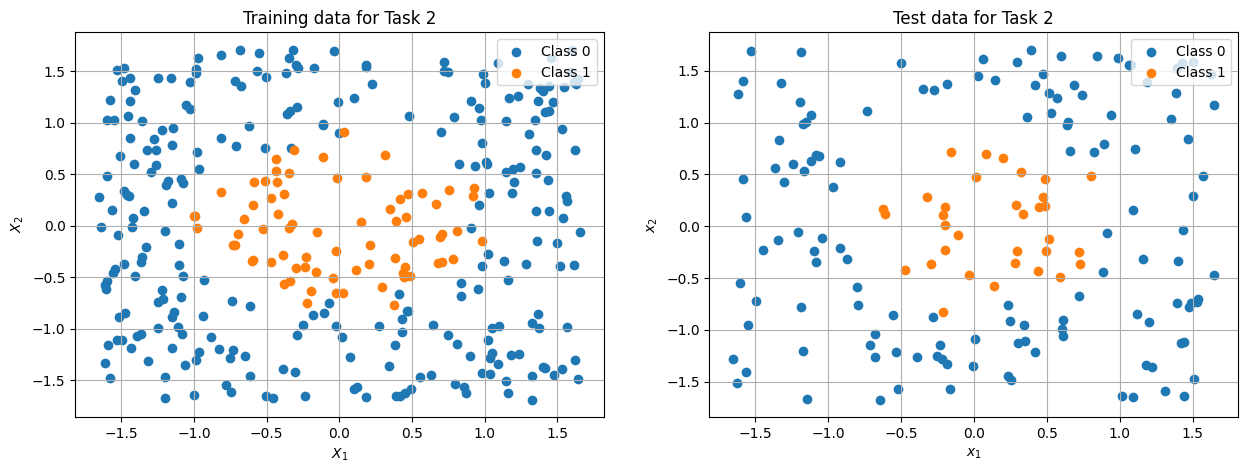

In [7]:
training_data_task2 = np.loadtxt("Et3_Task2_train.csv", delimiter=",")
X_Task2_training = training_data_task2[:,0:2]
y_Task2_training = training_data_task2[:,2]

print(np.shape(X_Task2_training))
print(np.shape(y_Task2_training))

test_data_task2 = np.loadtxt("Et3_Task2_test.csv", delimiter=",")
X_Task2_test = test_data_task2[:,0:2]
y_Task2_test = test_data_task2[:,2]

print(np.shape(X_Task2_test))
print(np.shape(y_Task2_test))

fig, axs = plt.subplots(1, 2, figsize=(15, 5)) 

axs[0].scatter(X_Task2_training[y_Task2_training==0][:,0],X_Task2_training[y_Task2_training==0][:,1], label="Class 0")
axs[0].scatter(X_Task2_training[y_Task2_training==1][:,0],X_Task2_training[y_Task2_training==1][:,1], label="Class 1")
axs[0].set_xlabel("$X_1$")
axs[0].set_ylabel("$X_2$")
axs[0].set_title("Training data for Task 2")
axs[0].legend(loc="upper right")
axs[0].grid()

axs[1].scatter(X_Task2_test[y_Task2_test==0][:,0],X_Task2_test[y_Task2_test==0][:,1], label="Class 0")
axs[1].scatter(X_Task2_test[y_Task2_test==1][:,0],X_Task2_test[y_Task2_test==1][:,1], label="Class 1")
axs[1].set_xlabel("$x_1$")
axs[1].set_ylabel("$x_2$")
axs[1].set_title("Test data for Task 2")
axs[1].legend(loc="upper right")
axs[1].grid()

### 2. Train a SVM model with a suitable kernel but otherwise all hyper parameters as default

In [8]:
# Radial basis function kernel (rbf, also called Gaussian kernel), suitable kernel with default parameters
support_vector_classifier_suitable_kernel_only_task2 = svm.SVC(kernel='rbf', random_state=0)

# fitting the model to the training data
support_vector_classifier_suitable_kernel_only_task2.fit(X_Task2_training, y_Task2_training)

SVC(random_state=0)

### 3. Visualise the support vectors and margin

SVM margins and support vectors for Task 2 (suitable kernel only)
Number of support vectors:  75
Performance during training:
Accuracy: 96.42%
E_in: 0.0358
Performance during testing:
Accuracy: 96.36%
E_out: 0.0364


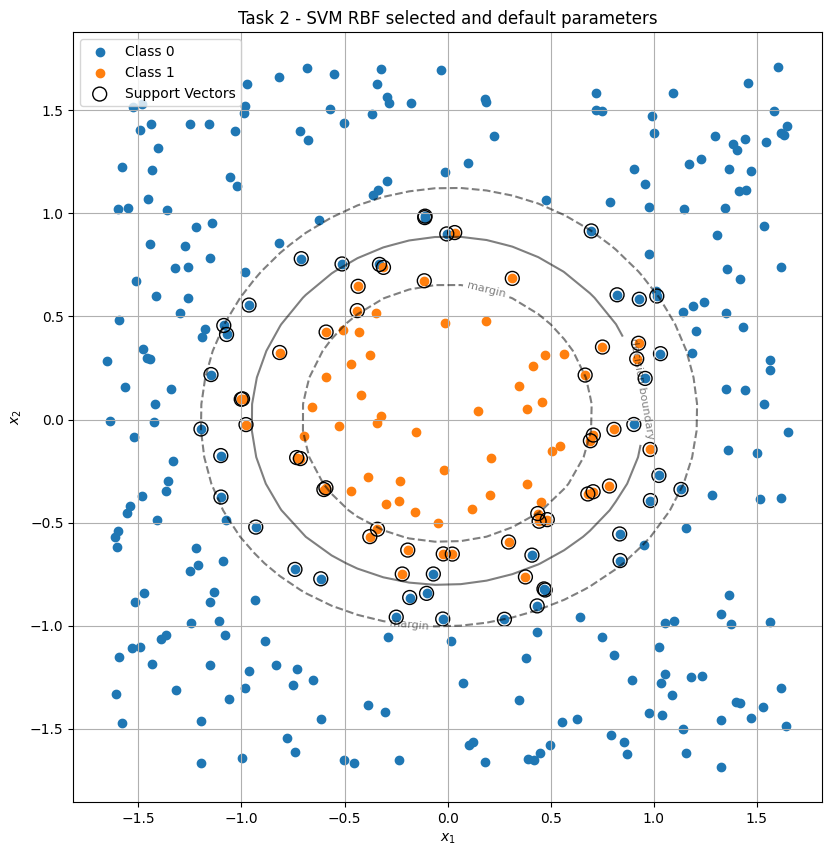

In [9]:
# Plotting the margins and support vectors
plt.figure(figsize=(10, 10))

plot_margin_with_extra_labels(X_Task2_training,
            y_Task2_training,
            support_vector_classifier_suitable_kernel_only_task2)

plt.title("Task 2 - SVM RBF selected and default parameters")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.grid()

print("SVM margins and support vectors for Task 2 (suitable kernel only)")
print("Number of support vectors: ", len(support_vector_classifier_suitable_kernel_only_task2.support_vectors_))

print("Performance during training:")
# check accuracy // E_in
accuracy = support_vector_classifier_suitable_kernel_only_task2.score(X_Task2_training, y_Task2_training)     
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")

print("Performance during testing:")
# check accuracy // E_out
accuracy = support_vector_classifier_suitable_kernel_only_task2.score(X_Task2_test, y_Task2_test)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_out: {1 - accuracy:.4f}")

### 4. Train a SVM model and optimise appropriate hyper parameters

In [85]:
# Bayes search

bayes_search = BayesSearchCV(
    svm.SVC(random_state=0, kernel='rbf'), # Pep recommends sticking with one kernel (discarded kernels: 'linear', 'poly', 'sigmoid')
    {
        'C': Real(1e-1, 1e+2, prior='log-uniform'),
        'gamma': Real(1e-4, 1e+1, prior='log-uniform'), #Categorical(['scale', 'auto']),
    },
    n_iter=50,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=0),
    scoring="accuracy",
    random_state=0, 
    verbose=0,
    n_jobs=-1
)

# executes bayesian optimization
_ = bayes_search.fit(X_Task2_training, y_Task2_training)
print(f"CV score: {bayes_search.best_score_:.2}")
print(f"Accuracy on training set: {bayes_search.score(X_Task2_training, y_Task2_training) * 100:.2f}%")
print(f"Accuracy on test set: {bayes_search.score(X_Task2_test, y_Task2_test) * 100:.2f}%")
print(f"Number of support vectors: {len(bayes_search.best_estimator_.support_vectors_)}")

print("Bayes search best hyper-parameters:", bayes_search.best_params_)



# Grid search

grid_search = GridSearchCV(
    svm.SVC(random_state=0, kernel='rbf'), # Pep recommends sticking with one kernel (discarded kernels: 'linear', 'poly', 'sigmoid')
    param_grid= {
        'C': np.logspace(-1,2,20),
        'gamma':np.logspace(-4,1,20),
    },
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=0),
    scoring="accuracy",
    verbose=0,
    n_jobs=-1
)
 
# executes grid search optimization
_ = grid_search.fit(X_Task2_training, y_Task2_training)
 
 
print(f"CV score: {grid_search.best_score_:.2}")
print(f"Accuracy on training set: {grid_search.score(X_Task2_training, y_Task2_training) * 100:.2f}%")
print(f"Accuracy on test set: {grid_search.score(X_Task2_test, y_Task2_test) * 100:.2f}%")
print(f"Number of support vectors: {len(grid_search.best_estimator_.support_vectors_)}")

print("Grid search best hyper-parameters:", grid_search.best_params_)

CV score: 0.97
Accuracy on training set: 97.61%
Accuracy on test set: 97.58%
Number of support vectors: 39
Bayes search best hyper-parameters: OrderedDict([('C', 39.556962940078456), ('gamma', 0.1504903887280296)])
CV score: 0.97
Accuracy on training set: 97.01%
Accuracy on test set: 98.79%
Number of support vectors: 110
Grid search best hyper-parameters: {'C': np.float64(0.20691380811147897), 'gamma': np.float64(0.8858667904100823)}


In [83]:
# print the final model with the best hyperparameters found

support_vector_classifier_tuned_hyperparameters_task2 = svm.SVC(**grid_search.best_params_, random_state=0)

support_vector_classifier_tuned_hyperparameters_task2.fit(X_Task2_training, y_Task2_training)

SVC(C=np.float64(0.20691380811147897), gamma=np.float64(0.8858667904100823),
    random_state=0)

### 5. Visualise the support vectors and margin

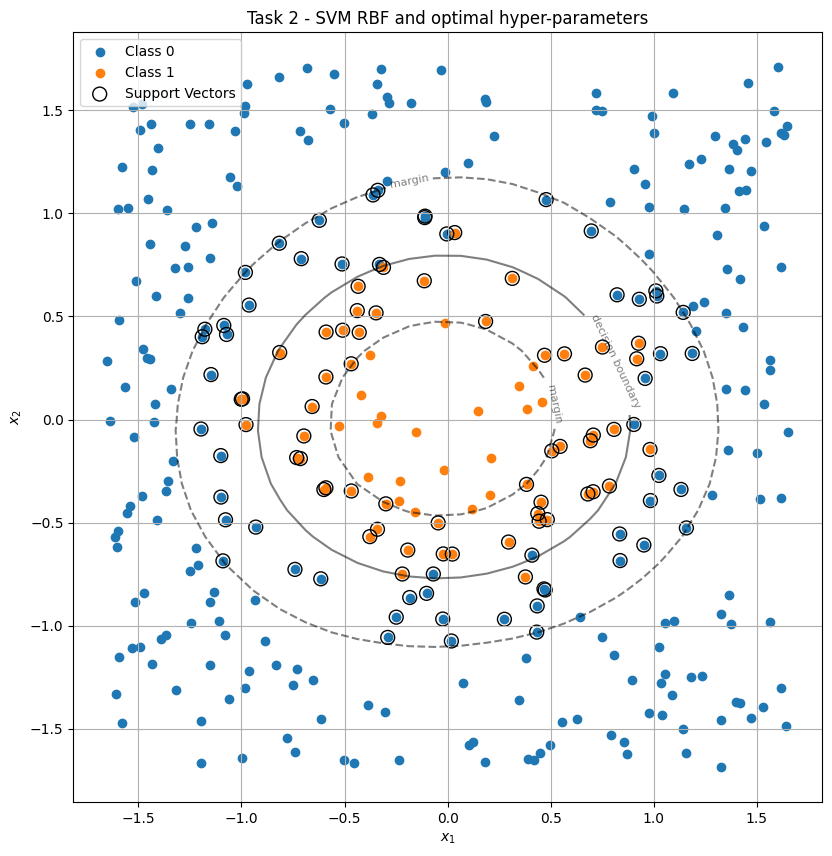

SVM margins and support vectors for Task 2 (optimal hyperparameters)
Number of support vectors:  110
Performance during training:
Accuracy: 97.01%
E_in: 0.0299
Performance during testing:
Accuracy: 98.79%
E_out: 0.0121


In [91]:
# Plotting the margins and support vectors
plt.figure(figsize=(10, 10))

plot_margin_with_extra_labels(X_Task2_training,
            y_Task2_training,
            support_vector_classifier_tuned_hyperparameters_task2)

plt.title("Task 2 - SVM RBF and optimal hyper-parameters")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.grid()
plt.show()

print("SVM margins and support vectors for Task 2 (optimal hyperparameters)")
print("Number of support vectors: ", len(support_vector_classifier_tuned_hyperparameters_task2.support_vectors_))

print("Performance during training:")
# check accuracy // E_in
accuracy = np.mean(support_vector_classifier_tuned_hyperparameters_task2.predict(X_Task2_training) == y_Task2_training)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")

print("Performance during testing:")
# check accuracy // E_out
accuracy = np.mean(support_vector_classifier_tuned_hyperparameters_task2.predict(X_Task2_test) == y_Task2_test)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_out: {1 - accuracy:.4f}")

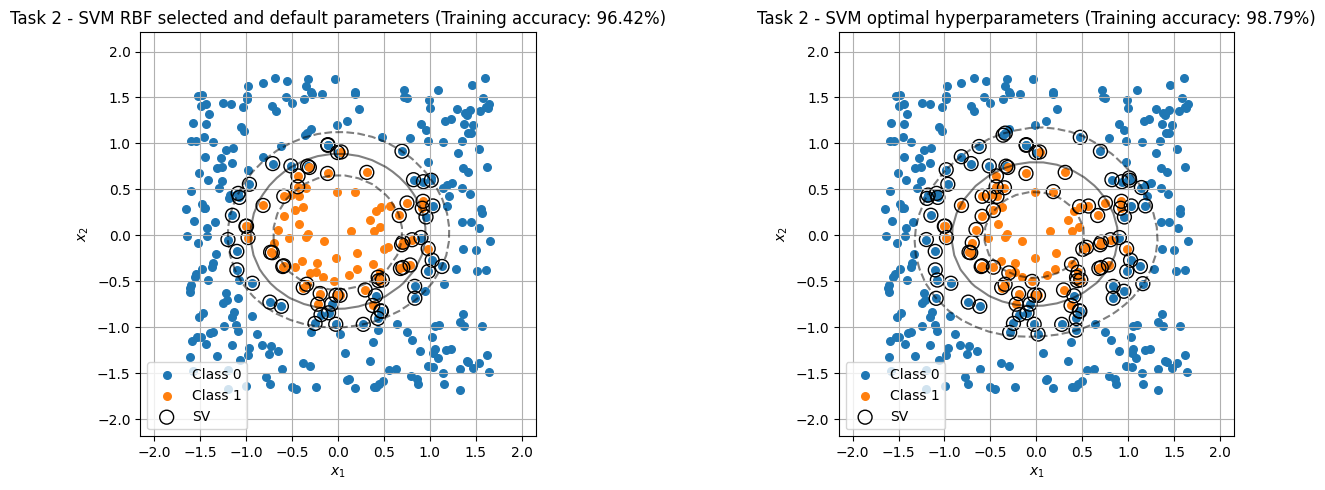

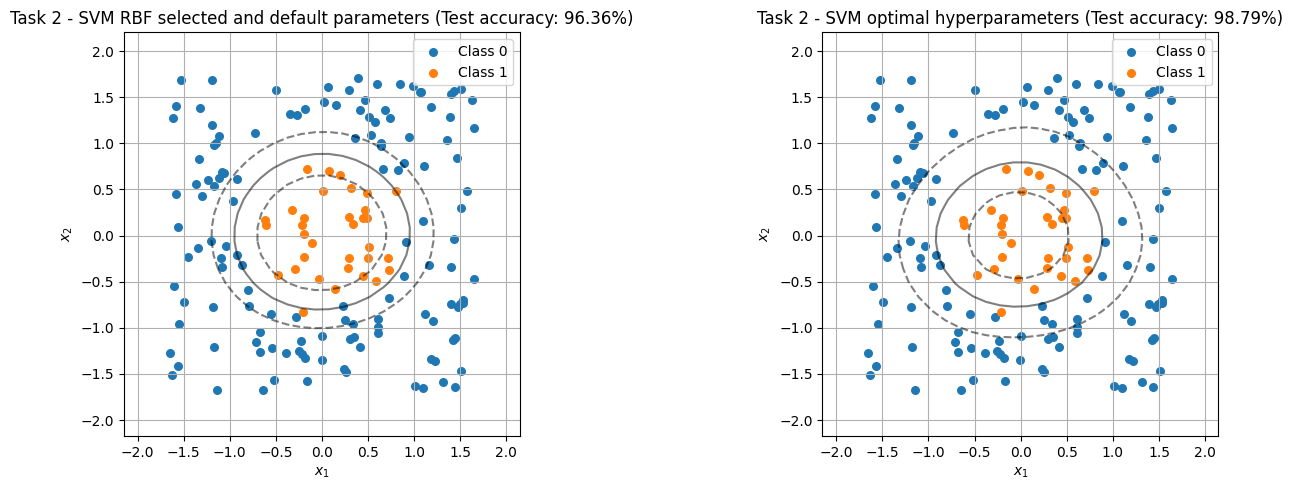

Model 1 hyper-parameters. C: 1.0, gamma: 0.4960759921388426
Model 2 hyper-parameters. C: 0.20691380811147897, gamma: 0.8858667904100823


In [105]:
# (OPTIONAL CELL, helps analysis)
# Plotting the margins and support vectors for both models side by side (training set)
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

plot_margin_comparasion(X_Task2_training,
            y_Task2_training,
            support_vector_classifier_suitable_kernel_only_task2,
            axs[0])

axs[0].set_title(f"Task 2 - SVM RBF selected and default parameters (Training accuracy: {support_vector_classifier_suitable_kernel_only_task2.score(X_Task2_training, y_Task2_training)*100:.2f}%)")
axs[0].set_xlabel("$x_1$")
axs[0].set_ylabel("$x_2$")
axs[0].grid()

plot_margin_comparasion(X_Task2_training,
            y_Task2_training,
            support_vector_classifier_tuned_hyperparameters_task2,
            axs[1])

axs[1].set_title(f"Task 2 - SVM optimal hyperparameters (Training accuracy: {support_vector_classifier_tuned_hyperparameters_task2.score(X_Task2_test, y_Task2_test)*100:.2f}%)")
axs[1].set_xlabel("$x_1$")
axs[1].set_ylabel("$x_2$")
axs[1].grid()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Plotting the margins for both models side by side (test set)
plot_margin_comparasion(X_Task2_test,
            y_Task2_test,
            support_vector_classifier_suitable_kernel_only_task2,
            axs[0], sv=False)

axs[0].set_title(f"Task 2 - SVM RBF selected and default parameters (Test accuracy: {support_vector_classifier_suitable_kernel_only_task2.score(X_Task2_test, y_Task2_test)*100:.2f}%)")
axs[0].set_xlabel("$x_1$")
axs[0].set_ylabel("$x_2$")
axs[0].grid()

plot_margin_comparasion(X_Task2_test,
            y_Task2_test,
            support_vector_classifier_tuned_hyperparameters_task2,
            axs[1], sv=False)

axs[1].set_title(f"Task 2 - SVM optimal hyperparameters (Test accuracy: {support_vector_classifier_tuned_hyperparameters_task2.score(X_Task2_test, y_Task2_test)*100:.2f}%)")
axs[1].set_xlabel("$x_1$")
axs[1].set_ylabel("$x_2$")
axs[1].grid()

plt.tight_layout()
plt.show()

print(f"Model 1 hyper-parameters. C: {support_vector_classifier_suitable_kernel_only_task2.get_params()['C']}, gamma: {support_vector_classifier_suitable_kernel_only_task2._gamma}")
print(f"Model 2 hyper-parameters. C: {support_vector_classifier_tuned_hyperparameters_task2.get_params()['C']}, gamma: {support_vector_classifier_tuned_hyperparameters_task2._gamma}")

### 6. Explain which model is the best model using the results from step 2-5 to provide as much evidence as possible for your claim (100 words max).

This data set called for a non-linearly separable SVM. The Gaussian kernel was expected to provide good results. With it, the first model achieved a test accuracy of $96.36%$. However, tuned hyper-parameters (C and gamma), increased the wiggliness of the second model (SVs: 75 -> 110) and widened the margin (we can check visually). 
The combination of higher reguralisation ($C$: 1 -> 0.21) and more local flexibility ($\gamma$: 0.50 -> 0.89), found by KFlod cross-validation with $k=10$ resulted in the test accuracy of the second model beating the former by 2.43% with no signs of overfitting.

# Task 3
## Task 3 code
This wrapper is required in below BayesSearchCV for a neural network to combine the two layer arguments (or more if you wish to experiment with more than two layers) into the single hidden_layer_sizes hyper-parameter.

In [23]:
class MLPWrapper(BaseEstimator, ClassifierMixin):
    
    def __init__(self, 
                 layer1=100, 
                 layer2=100, 
                 alpha=0.0001, 
                 activation='relu', 
                 learning_rate_init=1e-3,
                 early_stopping = False,
                 n_iter_no_change = 10,
                solver = 'adam'):
        self.layer1 = layer1
        self.layer2 = layer2
        self.alpha = alpha
        self.activation = activation
        self.learning_rate_init = learning_rate_init
        self.early_stopping = early_stopping
        self.n_iter_no_change = n_iter_no_change
        self.solver = solver

    def fit(self, X, y):
        model = MLPClassifier(
            hidden_layer_sizes=[self.layer1, self.layer2],
            alpha=self.alpha,
            max_iter = 1000,
            activation = self.activation,
            learning_rate_init = self.learning_rate_init,
            early_stopping = self.early_stopping,
            n_iter_no_change = self.n_iter_no_change,
            solver = self.solver,
            random_state=10
        )
        model.fit(X, y)
        self.model = model
        return self

    def predict(self, X):
        return self.model.predict(X)

    def score(self, X, y):
        return self.model.score(X, y)
    
    def get_model():
        return self.model

In [140]:
# Example use of BayesSearchCV to search a large search space whilst keeping compute requirements in check

optSVM1_lin = BayesSearchCV(
    svm.SVC(),
    {
      'C': Real(1e-3, 1e+3, prior='log-uniform'),
        'kernel': Categorical(['linear']),
    },
    n_iter=40,
)

In [141]:
# Example use of BayesSearchCV with the MLPWrapper to vary the layer sizes

optNN1 = BayesSearchCV(
    estimator=MLPWrapper(),
    search_spaces={
        'layer1': Integer(1, 100),
        'layer2': Integer(1, 100)
    },
    n_iter=40,
)

## Task 3 Instructions
1. Load dataset Et3_Task3_train and Et3_Task3_test.csv.
2. Train a SVM model with a suitable kernel but otherwise all hyper parameters as default
    - Print the performance on training data
    - Print the performance on test data
3. Train a SVM model and optimise appropriate hyper parameters
    - Try 2 searches: try both Grid-based searches and Bayesian searches. Note that these can take considerable time so set them up correctly first with a small number of feature dimensions / iterations to check correctness. Then increase the number of features dimensions / iterations and wait. You may wish to get a sense of train times with a relatively small number of iterations first.  
    - Keep track of the time required for the full search
    - Print the performance on training data
    - Print the performance on test data
    - Try to achieve a score of > 0.85 on test data for at least one of the searches
4. Train a neural network with a suitable activation function and guestimates for the hidden layer sizes but otherwise all hyper parameters as default
    - Print the performance on training data
    - Print the performance on test data
5. Train a neural network and optimise appropriate hyper parameters
    - Use 2 searches: try both Grid-based searches and Bayesian searches. Note that these can take considerable time so set them up correctly first with a small number of feature dimensions / iterations to check correctness. Then increase the number of features dimensions / iterations and wait. You may wish to get a sense of train times with a relative small number of iterations first.  
    - Keep track of the time required for the full search
    - Print the performance on training data
    - Print the performance on test data
    - Try to achieve a score of > 0.84 on test data for at least one of the searches
6. Answer the following questions:
   1. Explain the difference in performance between the two search strategies for each of the models (SVM and Neural Network). Point out any deviations (if any) from what you expected and potential fixes. If you ended up not using one of the search strategies for either step 3 or step 5, explain why (200 words max).
   2. Explain the major considerations when choosing between Bayesian and grid-based hyper-parameter optimisation (100 words max).
   2. When choosing the kernel type is part of SVM optimisation, what is key in reducing compute time as much as possible (100 words max)?  
    

## Task 3 Answer
We suggest to stick to the number of cells provided below.

### 1. Load dataset Et3_Task3_train and Et3_Task3_test.csv

In [20]:
training_data_task3 = np.loadtxt("Et3_Task3_train.csv", delimiter=",")
X_Task3_training = training_data_task3[:,0:20]
y_Task3_training = training_data_task3[:,20]

print(np.shape(X_Task3_training))
print(np.shape(y_Task3_training))


test_data_task3 = np.loadtxt("Et3_Task3_test.csv", delimiter=",")
X_Task3_test = test_data_task3[:,0:20]
y_Task3_test = test_data_task3[:,20]

print(np.shape(X_Task3_test))
print(np.shape(y_Task3_test))

(1750, 20)
(1750,)
(750, 20)
(750,)


### 2. Train a SVM model with a suitable kernel but otherwise all hyper parameters as default
    - Print the performance on training data
    - Print the performance on test data

In [21]:
# Radial basis function kernel (rbf, also called Gaussian kernel), suitable kernel with default parameters
support_vector_classifier_suitable_kernel_only_task3 = svm.SVC(kernel='rbf', random_state=0)

support_vector_classifier_suitable_kernel_only_task3.fit(X_Task3_training, y_Task3_training)
print("How many support vectors?", len(support_vector_classifier_suitable_kernel_only_task3.support_vectors_))

print("Performance:")
# check accuracy // E_in
print(f"Accuracy: {support_vector_classifier_suitable_kernel_only_task3.score(X_Task3_training, y_Task3_training) * 100:.2f}%")
print(f"E_in: {1 - support_vector_classifier_suitable_kernel_only_task3.score(X_Task3_training, y_Task3_training):.4f}")

print("Performance:")
# check accuracy // E_out
print(f"Accuracy: {support_vector_classifier_suitable_kernel_only_task3.score(X_Task3_test, y_Task3_test) * 100:.2f}%")
print(f"E_out: {1 - support_vector_classifier_suitable_kernel_only_task3.score(X_Task3_test, y_Task3_test):.4f}")

How many support vectors? 920
Performance:
Accuracy: 90.86%
E_in: 0.0914
Performance:
Accuracy: 84.53%
E_out: 0.1547


### 3. Train a SVM model and optimise appropriate hyper parameters
    - Use 2 searches: try both Grid-based searches and Bayesian searches. Note that these can take considerable time so set them up correctly first with a small number of feature dimensions / iterations to check correctness. Then increase the number of features dimensions / iterations and wait. You may wish to get a sense of train times with a relative small number of iterations first.  
    - Keep track of the time required for the full search
    - Print the performance on training data
    - Print the performance on test data

In [80]:
#Search 1

# share C and gamma search spaces across kernels
C_space_for_grid_search_for_SVM = [0.001, 0.1, 1, 10, 100, 1000]
gamma_space_for_grid_search_for_SVM = [0.001, 0.01, 0.1, 1, 10]

grid_search_for_SVM = GridSearchCV(
    svm.SVC(random_state=0, max_iter=1000),
    param_grid=[
    {   "kernel": ["rbf"],
        "C": C_space_for_grid_search_for_SVM,
        "gamma": gamma_space_for_grid_search_for_SVM
    },
    {   "kernel": ["poly"],
        "C": C_space_for_grid_search_for_SVM,
        "gamma": gamma_space_for_grid_search_for_SVM,
        "degree": [2, 3, 4, 5, 6, 7, 8],
        "coef0": [0, 0.1, 1]
    },
    {   "kernel": ["sigmoid"],
        "C": C_space_for_grid_search_for_SVM,
        "gamma": gamma_space_for_grid_search_for_SVM,
        "coef0": [0, 0.1, 1]
    }],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0),
    scoring="accuracy",
    verbose=3,
    n_jobs=-1
)

start = time.time()

# executes grid search optimization
_ = grid_search_for_SVM.fit(X_Task3_training, y_Task3_training)


end = time.time()
print(f"time taken searching: {end - start:.2f} seconds")
print(f"Test accuracy: {grid_search_for_SVM.score(X_Task3_test, y_Task3_test) * 100:.2f} - Training accuracy: {grid_search_for_SVM.score(X_Task3_training, y_Task3_training) * 100:.2f} - CV score: {grid_search_for_SVM.best_score_ * 100:.2f}")
print(f"Number of support vectors: {len(grid_search_for_SVM.best_estimator_.support_vectors_)}")

grid_search_for_SVM.best_params_

Fitting 5 folds for each of 750 candidates, totalling 3750 fits
time taken searching: 78.66 seconds
Test accuracy: 85.60 - Training accuracy: 86.34 - CV score: 84.69
Number of support vectors: 905


{'C': 0.1, 'coef0': 1, 'degree': 6, 'gamma': 0.01, 'kernel': 'poly'}

In [ ]:
#Search 2:

bayes_search_for_SVM = BayesSearchCV(
    svm.SVC(random_state=0, max_iter=1000),
    search_spaces=[
    {   "kernel": ["rbf"],
        "C": Real(1e-3, 1e+3, prior='log-uniform'), 
        "gamma": Real(1e-3, 1e+1, prior='log-uniform'),
    },
    {   "kernel": ["poly"],
        "C": Real(1e-3, 1e+3, prior='log-uniform'),
        "degree": Integer(2, 8),
        "gamma": Real(1e-3, 1e+1, prior='log-uniform'),
        "coef0": Real(0, 1e0, prior='uniform')
    },
    {   "kernel": ["sigmoid"],
        "C": Real(1e-3, 1e+3, prior='log-uniform'),
        "gamma": Real(1e-3, 1e+1, prior='log-uniform'),
        "coef0": Real(0, 1e0, prior='uniform')
    }],
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0),
    scoring="accuracy",
    random_state=0, 
    verbose=0,
    n_jobs=-1
)

print(f"Fitting {bayes_search_for_SVM.cv.get_n_splits()} folds for each of {bayes_search_for_SVM.n_iter} candidates, totalling {bayes_search_for_SVM.n_iter * bayes_search_for_SVM.cv.get_n_splits()} fits")

start = time.time()

# executes grid search optimization
_ = bayes_search_for_SVM.fit(X_Task3_training, y_Task3_training)

end = time.time()
print(f"time taken searching: {end - start:.2f} seconds")
print(f"Test accuracy: {bayes_search_for_SVM.score(X_Task3_test, y_Task3_test) * 100:.2f} - Training accuracy: {bayes_search_for_SVM.score(X_Task3_training, y_Task3_training) * 100:.2f} - CV score: {bayes_search_for_SVM.best_score_ * 100:.2f}")

print(f"Number of support vectors: {len(bayes_search_for_SVM.best_estimator_.support_vectors_)}")

bayes_search_for_SVM.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
time taken searching: 328.23 seconds
Test accuracy: 85.07 - Training accuracy: 86.40 - CV score: 84.63
Number of support vectors: 753


OrderedDict([('C', 2.05680078008492),
             ('gamma', 0.008647044605162803),
             ('kernel', 'rbf')])

In [110]:
support_vector_classifier_tuned_hyperparameters_task3 = svm.SVC(**grid_search_for_SVM.best_params_, random_state=0)
 
_ = support_vector_classifier_tuned_hyperparameters_task3.fit(X_Task3_training, y_Task3_training)
 

print("SVM with tuned hyperparameters")

print("Performance during training:")
# check accuracy // E_in
print(f"Training accuracy: {support_vector_classifier_tuned_hyperparameters_task3.score(X_Task3_training, y_Task3_training) * 100:.2f}%")
print(f"E_in: {1 - support_vector_classifier_tuned_hyperparameters_task3.score(X_Task3_training, y_Task3_training):.4f}")

print("Performance during testing:")
# check accuracy // E_out
print(f"Testing accuracy: {support_vector_classifier_tuned_hyperparameters_task3.score(X_Task3_test, y_Task3_test) * 100:.2f}%")
print(f"E_out: {1 - support_vector_classifier_tuned_hyperparameters_task3.score(X_Task3_test, y_Task3_test):.4f}")

print("Number of support vectors:", len(support_vector_classifier_tuned_hyperparameters_task3.support_vectors_))

print("Performance over 0.85? ", support_vector_classifier_tuned_hyperparameters_task3.score(X_Task3_test, y_Task3_test) > 0.85)

SVM with tuned hyperparameters
Performance during training:
Training accuracy: 86.34%
E_in: 0.1366
Performance during testing:
Testing accuracy: 85.60%
E_out: 0.1440
Number of support vectors: 905
Performance over 0.85?  True


### 4. Train a neural network with a suitable activation function and guestimates for the hidden layer sizes but otherwise all hyper parameters as default
    - Print the performance on training data
    - Print the performance on test data

In [61]:
#without hyper parameters to reguralise, it's better to keep the amount of weights fairly small

mlp_activation_function_and_hidden_sizes_only_task3 = MLPWrapper(layer1=4, layer2=3, activation='relu')

mlp_activation_function_and_hidden_sizes_only_task3.fit(X_Task3_training, y_Task3_training)

print("Performance on training data:")
# check accuracy // E_in
accuracy = mlp_activation_function_and_hidden_sizes_only_task3.score(X_Task3_training, y_Task3_training)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")


print("Performance on test data:")
# check accuracy // E_out
accuracy = mlp_activation_function_and_hidden_sizes_only_task3.score(X_Task3_test, y_Task3_test)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_out: {1 - accuracy:.4f}")

print(f"Number of weights (layer 1): {mlp_activation_function_and_hidden_sizes_only_task3.get_params()['layer1']}")
print(f"Number of weights (layer 2): {mlp_activation_function_and_hidden_sizes_only_task3.get_params()['layer2']}")
print("Number of weights: (N_l1 + 1) * N_2 = ", (mlp_activation_function_and_hidden_sizes_only_task3.get_params()['layer1'] + 1) * mlp_activation_function_and_hidden_sizes_only_task3.get_params()['layer2'])

Performance on training data:
Accuracy: 85.89%
E_in: 0.1411
Performance on test data:
Accuracy: 83.87%
E_out: 0.1613
Number of weights (layer 1): 4
Number of weights (layer 2): 3
Number of weights: (N_l1 + 1) * N_2 =  15


### 5. Train a neural network and optimise appropriate hyper parameters
    - Use 2 searches: try both Grid-based searches and Bayesian searches. Note that these can take considerable time so set them up correctly first with a small number of feature dimensions / iterations to check correctness. Then increase the number of features dimensions / iterations and wait. You may wish to get a sense of train times with a relative small number of iterations first.  
    - Keep track of the time required for the full search
    - Print the performance on training data
    - Print the performance on test data

In [ ]:
#Search 1

grid_search_for_MLP = GridSearchCV(
    MLPWrapper(),
    param_grid=[{
        'activation': ['identity', 'relu', 'logistic', 'tanh'],
        'alpha': [0.0001, 0.001, 0.01],
        'early_stopping': [False, True],
        'layer1': [1, 5, 10, 100],
        'layer2': [1, 3, 5],
        'learning_rate_init': [1e-4, 1e-3, 1e-2, 1e-1],
        'solver': ['adam', 'sgd']
    },
    {
        'activation': ['identity', 'relu', 'logistic', 'tanh'],
        'alpha': [0.0001, 0.001, 0.01],
        'layer1': [1, 5, 10, 100],
        'layer2': [1, 3, 5,],
        'solver': ['lbfgs']
    }],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0),
    scoring="accuracy",
    verbose=3,
    n_jobs=-1
)

start = time.time()

# executes grid search optimization
_ = grid_search_for_MLP.fit(X_Task3_training, y_Task3_training)

end = time.time()
print(f"time taken searching: {end - start:.2f} seconds")
print(f"Test accuracy: {grid_search_for_MLP.score(X_Task3_test, y_Task3_test) * 100:.2f} - Training accuracy: {grid_search_for_MLP.score(X_Task3_training, y_Task3_training) * 100:.2f} - CV score: {grid_search_for_MLP.best_score_ * 100:.2f}")
print(f"Number of weights: (N_l1 + 1) * N_l2 = {(grid_search_for_MLP.best_params_['layer1'] + 1) * grid_search_for_MLP.best_params_['layer2']}, with N_l1 = {grid_search_for_MLP.best_params_['layer1']} and N_l2 = {grid_search_for_MLP.best_params_['layer2']}")

grid_search_for_MLP.best_params_

Fitting 5 folds for each of 2448 candidates, totalling 12240 fits


time taken searching: 1812.88 seconds
Test accuracy: 84.67 - Training accuracy: 84.69 - CV score: 85.09
Number of weights: (N_l1 + 1) * N_l2 = 55, with N_l1 = 10 and N_l2 = 5


{'activation': 'identity',
 'alpha': 0.0001,
 'early_stopping': False,
 'layer1': 10,
 'layer2': 5,
 'learning_rate_init': 0.1,
 'solver': 'adam'}

In [108]:
#Search 2

bayes_search_for_MLP = BayesSearchCV(
    estimator=MLPWrapper(),
    search_spaces=[{   
        'activation': Categorical(['identity', 'relu', 'logistic', 'tanh']),
        'alpha': Real(1e-4, 1e-2, prior='log-uniform'),
        'early_stopping': Categorical([False, True]),
        'layer1': Integer(1, 100),
        'layer2': Integer(1, 10),
        'learning_rate_init': Real(1e-4, 1e-1, prior='log-uniform'),
        'solver': Categorical(['adam', 'sgd'])
    },
    {   
        'activation': Categorical(['identity', 'relu', 'logistic', 'tanh']),
        'alpha': Real(1e-4, 1e-2, prior='log-uniform'),
        'layer1': Integer(1, 100),
        'layer2': Integer(1, 10),
        'solver': Categorical(['lbfgs'])
    }],
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0),
    scoring="accuracy",
    verbose=0,
    n_jobs=-1
)

print(f"Fitting {bayes_search_for_MLP.cv.get_n_splits()} folds for each of {bayes_search_for_MLP.n_iter} candidates, totalling {bayes_search_for_MLP.n_iter * bayes_search_for_MLP.cv.get_n_splits()} fits")

start = time.time()

# executes grid search optimization
_ = bayes_search_for_MLP.fit(X_Task3_training, y_Task3_training)

end = time.time()

print(f"time taken searching: {end - start:.2f} seconds")
print(f"Test accuracy: {bayes_search_for_MLP.score(X_Task3_test, y_Task3_test) * 100:.2f} - Training accuracy: {bayes_search_for_MLP.score(X_Task3_training, y_Task3_training) * 100:.2f} - CV score: {bayes_search_for_MLP.best_score_ * 100:.2f}")
print(f"Number of weights: (N_l1 + 1) * N_l2 = {(bayes_search_for_MLP.best_params_['layer1'] + 1) * bayes_search_for_MLP.best_params_['layer2']}, with N_l1 = {bayes_search_for_MLP.best_params_['layer1']} and N_l2 = {bayes_search_for_MLP.best_params_['layer2']}")

bayes_search_for_MLP.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
time taken searching: 369.49 seconds
Test accuracy: 85.07 - Training accuracy: 84.97 - CV score: 84.51
Number of weights: (N_l1 + 1) * N_l2 = 252, with N_l1 = 62 and N_l2 = 4


OrderedDict([('activation', 'identity'),
             ('alpha', 0.00010565568703582734),
             ('layer1', 62),
             ('layer2', 4),
             ('solver', 'lbfgs')])

In [109]:
multi_layer_perceptron_tuned_hyperparameters_task3 = MLPWrapper(**bayes_search_for_MLP.best_params_)
 
_ = multi_layer_perceptron_tuned_hyperparameters_task3.fit(X_Task3_training, y_Task3_training)
 

print("MLP with tuned hyperparameters")

print("Performance during training:")
# check accuracy // E_in
accuracy = np.mean(multi_layer_perceptron_tuned_hyperparameters_task3.predict(X_Task3_training) == y_Task3_training)       
print(f"Accuracy: {accuracy * 100:.2f}%")

print("Performance during testing:")
# check accuracy // E_out
print(f"Accuracy: {multi_layer_perceptron_tuned_hyperparameters_task3.score(X_Task3_test, y_Task3_test) * 100:.2f}%")

print(f"Number of weights (layer 1): {multi_layer_perceptron_tuned_hyperparameters_task3.get_params()['layer1']}")
print(f"Number of weights (layer 2): {multi_layer_perceptron_tuned_hyperparameters_task3.get_params()['layer2']}")
print("Number of weights: (N_l1 + 1) * N_2 = ", (multi_layer_perceptron_tuned_hyperparameters_task3.get_params()['layer1'] + 1) * multi_layer_perceptron_tuned_hyperparameters_task3.get_params()['layer2'])
print("Performance over 0.84? ", multi_layer_perceptron_tuned_hyperparameters_task3.score(X_Task3_test, y_Task3_test) > 0.84)

MLP with tuned hyperparameters
Performance during training:
Accuracy: 84.97%
Performance during testing:
Accuracy: 85.07%
Number of weights (layer 1): 62
Number of weights (layer 2): 4
Number of weights: (N_l1 + 1) * N_2 =  252
Performance over 0.84?  True


6. Answer the following questions:
   
<b>1. Explain the difference in performance between the two search strategies for each of the models (SVM and Neural Network). Point out any deviations (if any) from what you expected and potential fixes. If you ended up not using one of the search strategies for either step 3 or step 5, explain why (200 words max).</b>
   
All searches were capped to 1000 iterations. <code>MLPWrapper</code> (provided) had this limitation. Modifying the stud was an option, but I left it like that because not limiting the number of iterations made certain tests unfeasible otherwise.

SVM:

With 750 models and 3750 cross-validation folds, for SVMs the grid search is fast (1m:31s) and provides acceptable results (85.60). I was surprised by the picked values, I wasn't expecting the polynomial kernel to be selected. But there are no signs of the search being ill. Bayes picked the same kernel that <code>support_vector_classifier_suitable_kernel_only_task3</code> uses. The former shows signs of overfitting. Bayes corrected this with only 50 models and 250 cross-validation folds, but taking ~5 times more (5m:47s) than grid search.

NN:

Grid search becomes a burdensome run when using a more complex model in terms of search space (~6 hyperparameters vs ~2) and it's also more compute-intensive to train. It reaches acceptable results, but the regularisation value ($\alpha$) sits at the border of the selected range, which maybe calls for a new search with a wider range to inspect this, but with that processing time (30m:21s), pursuing this is masochistic. Bayes becomes the champion with better test results and only 6 minutes searching.

<b>2. Explain the major considerations when choosing between Bayesian and grid-based hyper-parameter optimisation (100 words max). </b>

Grid search is an exhaustive method and must be used carefully not to sky rocket the training and evaluation times into unfeasible waiting times/number of executions. Bayes is an stochastic method, this means that it learns from its previous iterations and can find convergence points thanks to this. This doesn't mean that it's perfect, Bayes can report a local point of convergence instead of a global. Grid search makes no assumptions but if your ranges are not extensive enough, it could easily skip the best hyper parameters, however, being too broad will be costly.

<b>2. When choosing the kernel type is part of SVM optimisation, what is key in reducing compute time as much as possible (100 words max)?</b>

Discarding kernels that are unlikely to help. Example: the linear kernel is a poor choice if the data set is not linearly separable. Using individual spaces for each promising kernel is vital, only relevant hyper-parameters to the specific kernel should be explored for the subspace (i.e. don't mix 'polynomial degree' with the 'RBF' kernel). Use as much parallel programming as possible. Take in consideration only the hyper-parameters that affect the model the most. And compromise... If the hyper-parameters found generalise to the desired accuracy and they don't sit at the border for your space search, you already have suitable solution.

# Reflection

<b>Clearly describe the changes you have made based on your peers' work and feedback (100 words max).</b>

Dermot's submission helped me improved my answers for task 1 by making me question how to find my soft and hard SVs. We both decided to use a 'very large' C value after discussing that from a theoretical point of view this makes more correct. Lori's searches were more efficient than mine for task 3.3, I started using subspaces after seeing her notebook. I got the idea of putting my SVM plots for task 2 side by side from Sara's notebook. And Pat's plots also gave me ideas about extra labels I could use. Daniel questions during class were insightful. 

Describe your understanding of:

<b>1. How hyper-parameters effect complexity and what our goal is in tuning hyper parameters (100 words max).</b>

Hyper-parameters are a game changer. They can take high complex models and by 'applying the breaks' virtually reduce them to a cost-efficient model that we can afford with a data set that otherwise would end up generalising poorly. Or can improve the performance (time or quality-wise). The goal when we are tunning, is to find a combination that 'applies the breaks' just the right amount. As we saw in the previous e-tivity, too much regulasition will overfit, and too little will underfit. By using a methodology like Bayes or Grid search, we look for that balance across a reasonable space.

<b>2. What aspects of your machine learning model determine whether a grid search (GS) or a Bayesian search (BS) is most appropriate, and why (150 words max).</b>

The number of hyper-parameters, their ranges and how costly it's to execute the model. 

GS sees all combinations of the search space. If there are many of them, it loses appeal because every new value added to the space will increase the number of executions. If in addition, your model is also compute-intensive to train, GS becomes unfeasible unless you have an plenty of resources and/or patience. 

BS uses probabilistic machine learning. It doesn't try every single combination in the search space. With a stochastic behaviour, it starts somewhat randomly and will then focus on the areas where the representation of the real cost function for each hyperparameter is likely to reduce. But each iteration of this search can also be costly because it's learning from every iteration. And it could end up converging to a local instead of global point.

In practical terms, use GS if your search space is small and training your model is not taxing, otherwise approach it with Bayes.